# Week 2
## 1.Work flow Continue

In [17]:
#2026-5-14
# This block is to import the result and workflow last time.
import numpy as np
import pandas as pd
from scipy.fftpack import dct, idct
from pathlib import Path
import matplotlib.pyplot as plt
from kilosort.io import load_ops

SAVE_PATH = Path('F:\\ACADEMIC') / '.test_data' / 'ZFM-02370_mini.imec0.ap.short.bin'

n_chan = 385          # channel number
N = 267 # Neuron Number
dtype = 'int16'

# Load the saved Sorting results from the local drive.
results_dir = SAVE_PATH.parent / 'kilosort4'
ops = load_ops(results_dir / 'ops.npy')
camps = pd.read_csv(results_dir / 'cluster_Amplitude.tsv', sep='\t')['Amplitude'].values
contam_pct = pd.read_csv(results_dir / 'cluster_ContamPct.tsv', sep='\t')['ContamPct'].values
chan_map =  np.load(results_dir / 'channel_map.npy')
templates =  np.load(results_dir / 'templates.npy')
chan_best = (templates**2).sum(axis=1).argmax(axis=-1)
chan_best = chan_map[chan_best]
amplitudes = np.load(results_dir / 'amplitudes.npy')
st = np.load(results_dir / 'spike_times.npy')
clu = np.load(results_dir / 'spike_clusters.npy')

fs = ops['fs']
firing_rates = np.unique(clu, return_counts=True)[1] * fs / st.max()
dshift = ops['dshift']

In [31]:
# Get the spike time for each neuron.
unique_clusters = np.unique(clu)

spikes_by_cluster = {}

for cluster_id in unique_clusters:
    times = st[clu == cluster_id] / fs  # fs is the sampling frequency。
    spikes_by_cluster[cluster_id] = times

for cluster_id in unique_clusters[:5]:
    print(f"Cluster {cluster_id}: {len(spikes_by_cluster[cluster_id])} spikes")

Cluster 0: 748 spikes
Cluster 1: 605 spikes
Cluster 2: 1175 spikes
Cluster 3: 1351 spikes
Cluster 4: 1464 spikes


## 2. DCT for original

In [5]:
def compress_signal_dct(signal, keep_ratio=0.1): #signal: input singal, e.g. a part of data in a certain channel.
    
    n = len(signal)
    dct_coeffs = dct(signal, norm='ortho')
    
    cutoff = int(n * keep_ratio) # the number of remaining parameters
    compressed_coeffs = np.zeros(n)
    compressed_coeffs[:cutoff] = dct_coeffs[:cutoff]
    
    # inverse DCT to recover the signal
    reconstructed_signal = idct(compressed_coeffs, norm='ortho')
    
    return reconstructed_signal, compressed_coeffs

In [35]:
np.memmap?

Init signature:
np.memmap(
    filename,
    dtype=<class 'numpy.uint8'>,
    mode='r+',
    offset=0,
    shape=None,
    order='C',
)
Docstring:     
Create a memory-map to an array stored in a *binary* file on disk.

Memory-mapped files are used for accessing small segments of large files
on disk, without reading the entire file into memory.  NumPy's
memmap's are array-like objects.  This differs from Python's ``mmap``
module, which uses file-like objects.

This subclass of ndarray has some unpleasant interactions with
some operations, because it doesn't quite fit properly as a subclass.
An alternative to using this subclass is to create the ``mmap``
object yourself, then create an ndarray with ndarray.__new__ directly,
passing the object created in its 'buffer=' parameter.

This class may at some point be turned into a factory function
which returns a view into an mmap buffer.

Flush the memmap instance to write the changes to the file. Currently there
is no API to close the underl

In [37]:
# Use memmap method to read the portion of data when accessing a specific slice to save memory.
# N=length of (unique_units = np.unique(clu))

file_size_bytes = SAVE_PATH.stat().st_size
total_samples = file_size_bytes // (2 * n_chan) # dtype='int16' 2bytes for each poiny

data = np.memmap(SAVE_PATH, dtype=dtype, mode='r', shape=(total_samples, n_chan))

In [38]:
data

memmap([[-28, -27, -41, ...,  -6,  15,  64],
        [-35, -22, -37, ...,  -6,  23,  64],
        [-20, -15, -21, ...,  -7,  24,  64],
        ...,
        [-11, -30, -17, ...,  -9,  21,  64],
        [-13, -31, -21, ..., -14,  22,  64],
        [-12, -30, -25, ..., -12,  11,  64]],
       shape=(1350000, 385), dtype=int16)

### Data Structure Visualization

| (1,350,000 Rows) | Channel 0 | Channel 1 | Channel 2 | ... | Channel 384 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Sample 0** | -28 | -27 | -41 | ... | 64 |
| **Sample 1** | -35 | -22 | -37 | ... | 64 |
| **Sample 2** | -20 | -15 | -21 | ... | 64 |
| **...** | ... | ... | ... | ... | ... |
| **Sample 1,349,997** | -11 | -30 | -17 | ... | 64 |
| **Sample 1,349,998** | -13 | -31 | -21 | ... | 64 |
| **Sample 1,349,999** | -12 | -30 | -25 | ... | 64 |
| | **$\uparrow$** | **$\uparrow$** | **$\uparrow$** | | **$\uparrow$** |
| | **385 Channels** | **(Columns)** | | | |

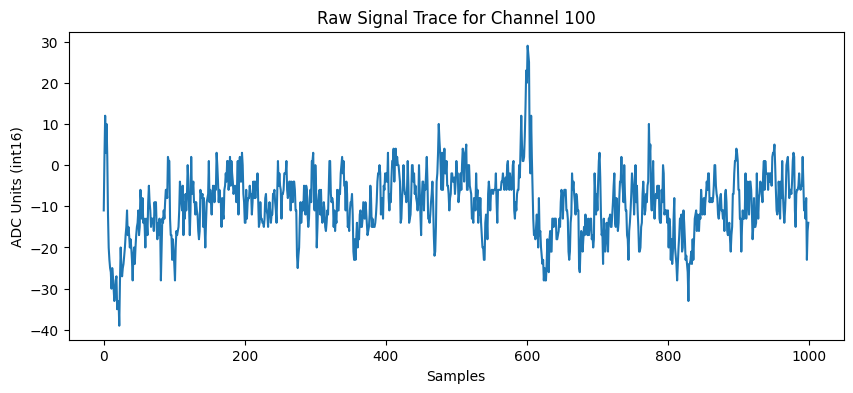

In [39]:
import matplotlib.pyplot as plt

sample_segment = data[0:1000, :] 

plt.figure(figsize=(10, 4))
channel_no=100
plt.plot(sample_segment[:, channel_no])
plt.title(f"Raw Signal Trace for Channel {channel_no}")
plt.xlabel("Samples")
plt.ylabel("ADC Units (int16)")
plt.show()

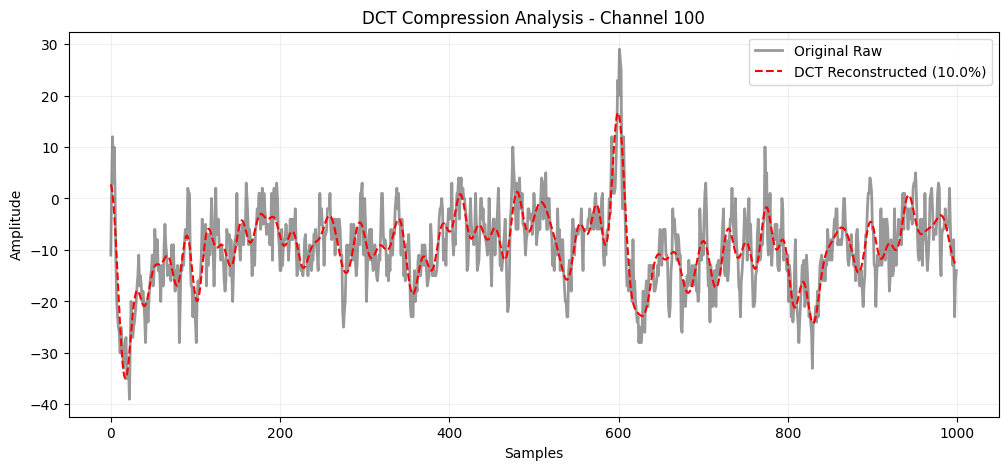

Oringinal sample number: 1000
DCT Sample Number: 100


In [43]:
channel_no=100
raw_signal = data[0:1000, channel_no].astype(np.float32)

keep_ratio = 0.1
reconstructed, coeffs = compress_signal_dct(raw_signal, keep_ratio=keep_ratio)

plt.figure(figsize=(12, 5))

plt.plot(raw_signal, label='Original Raw', color='black', alpha=0.4, linewidth=2)

plt.plot(reconstructed, label=f'DCT Reconstructed ({keep_ratio*100}%)', color='red', linestyle='--')

plt.title(f"DCT Compression Analysis - Channel {channel_no}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Oringinal sample number: {len(raw_signal)}")
print(f"DCT Sample Number: {int(len(raw_signal) * keep_ratio)}")

In [46]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_compression_interactive(channel_no, keep_ratio, sample_range):
    start, end = sample_range
    raw_signal = data[start:end, channel_no].astype(np.float32)
    
    reconstructed, _ = compress_signal_dct(raw_signal, keep_ratio=keep_ratio)
    
    plt.figure(figsize=(12, 5))
    plt.plot(raw_signal, label='Original Raw', color='black', alpha=0.4, linewidth=2)
    plt.plot(reconstructed, label=f'DCT Reconstructed ({keep_ratio*100:.1f}%)', 
             color='red', linestyle='--')
    
    plt.title(f"Interactive DCT Compression - Channel {channel_no}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()
    
    print(f"Current sample number:  {len(raw_signal)}")
    print(f"Para remaining: {int(len(raw_signal) * keep_ratio)}")
    print(f"Compression Ratio(1/keep_ratio): {1/keep_ratio:.1f}x")

interact(
    plot_compression_interactive, 
    channel_no = widgets.IntText(value=100, description='Channel:'),
    keep_ratio = widgets.FloatSlider(value=0.1, min=0.001, max=1.0, step=0.01, 
                                     description='Keep Ratio:', continuous_update=False),
    sample_range = widgets.IntRangeSlider(value=[0, 1000], min=0, max=20000, step=100,
                                          description='Time Range:', continuous_update=False)
);

interactive(children=(IntText(value=100, description='Channel:'), FloatSlider(value=0.1, continuous_update=Fal…

In [54]:
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
import numpy as np

#interact modules initial
cluster_input = widgets.IntText(value=0, description='Cluster ID:')
keep_ratio_slider = widgets.FloatSlider(value=0.1, min=0.001, max=0.5, step=0.01, description='Keep Ratio:', continuous_update=False)
spike_no_slider = widgets.IntSlider(value=0, min=0, max=100, description='Spike No.', continuous_update=False)

def plot_waveforms_stack_compression(cluster_id, keep_ratio, spike_no):
    unit_spike_times = st[clu == cluster_id]
    if len(unit_spike_times) == 0:
        print(f"Cluster {cluster_id} has no spikes.")
        return
    total_spikes = len(unit_spike_times)
    print(f"The total spike number for this neuron is{}")
    spike_no_slider.max = total_spikes - 1
    
    idx = min(spike_no, total_spikes - 1)
    center_sample = int(unit_spike_times[idx])
    
    best_ch = chan_best[cluster_id]
    ch_range = 10 # +-10 channels near the best channel
    start_ch = max(0, best_ch - ch_range)
    end_ch = min(384, best_ch + ch_range)
    channels_to_plot = range(start_ch, end_ch + 1)

    # time window
    window = 60 
    start_t = max(0, center_sample - window)
    end_t = min(data.shape[0], center_sample + window)
    
    plt.figure(figsize=(14, 7))
    
    for ch in channels_to_plot:
        raw_ch = data[start_t:end_t, ch].astype(np.float32)
        
        # optimized
        recon_ch, _ = compress_signal_dct(raw_ch, keep_ratio=keep_ratio)
        
        alpha = 1.0 if ch == best_ch else 0.15
        color = 'red' if ch == best_ch else 'gray'
        lw = 2.5 if ch == best_ch else 0.8
        
        if ch == best_ch:
            plt.plot(raw_ch, color='black', alpha=0.5, label='Original (Best Ch)')
            plt.plot(recon_ch, color='red', linestyle='--', linewidth=lw, label=f'Recon (Best Ch, {keep_ratio*100:.1f}%)')
        else:
            plt.plot(raw_ch, color='gray', alpha=alpha, linewidth=lw)
            plt.plot(recon_ch, color='red', alpha=alpha/2, linestyle='--', linewidth=lw)

    plt.title(f"Neuron No. {cluster_id} (Best Ch: {best_ch}) - Spike #{idx}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.1)
    plt.show()
    
    print(f"Showing channels: {start_ch} to {end_ch}")

interact(plot_waveforms_stack_compression, 
         cluster_id=cluster_input, 
         keep_ratio=keep_ratio_slider, 
         spike_no=spike_no_slider);

interactive(children=(IntText(value=0, description='Cluster ID:'), FloatSlider(value=0.1, continuous_update=Fa…